In [19]:
# Customer Segmentation with K-Means

# Huawei Data Science & Machine Learning Bootcamp
# Author: Nida Özbey

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [21]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

In [22]:
df.shape

(2240, 29)

In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [25]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [26]:
# Income sütununda eksik değer (NaN) bulunan müşterileri veri setinden çıkarıyoruz.
# K-Means modeli eksik değerlerle çalışamayacağı için bu temizliği yapıyoruz.
df = df.dropna(subset=['Income'])

In [27]:
df.shape

(2216, 29)

In [28]:
# Farklı ürün kategorilerindeki harcamaları toplayarak
# müşterinin toplam harcamasını gösteren yeni bir değişken oluşturuyoruz.
df['Total_Spend'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [29]:
df[['MntWines', 'MntFruits', 'MntMeatProducts',
   'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
   'Total_Spend']].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spend
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


In [30]:
# 1. Aykırı değer temizliği: Geliri 150.000'den küçük olanları alıyoruz
df = df[df['Income'] < 150000]

# 2. Modele sokacağımız iki ana değişkeni (feature) seçiyoruz
features = ['Income', 'Total_Spend']
X = df[features]

# 3. Verileri StandardScaler ile ölçeklendiriyoruz
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# İşlem sonucuna bakalım (ilk 5 satırın ölçeklenmiş hali)
print(X_scaled[:5])

[[ 0.31408859  1.67807547]
 [-0.2554309  -0.96332276]
 [ 0.96478175  0.28095854]
 [-1.20662599 -0.92013009]
 [ 0.32157337 -0.30712635]]


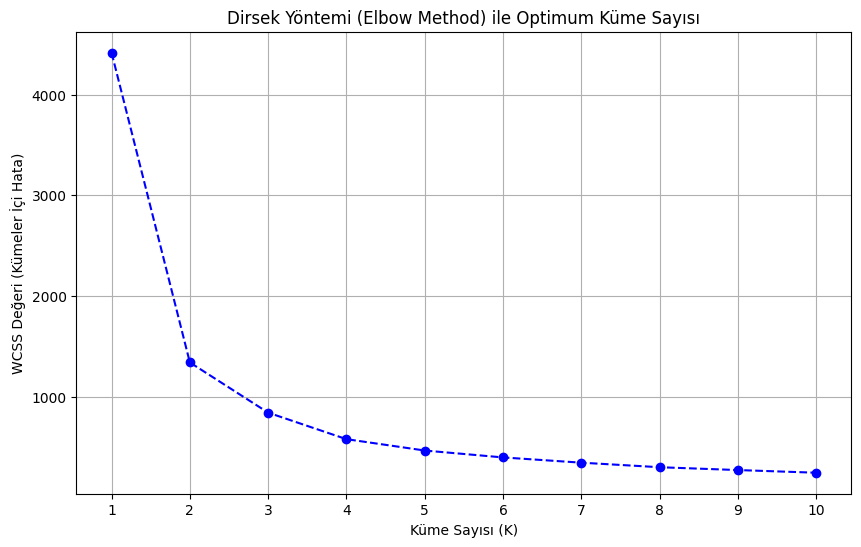

In [31]:
# Hata değerlerini (WCSS) tutacağımız boş bir liste oluşturuyoruz
wcss = []

# K=1'den K=10'a kadar modelleri deniyoruz
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ bize hatayı (WCSS) verir

# Dirsek Yöntemi Grafiğini Çizdirme
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Dirsek Yöntemi (Elbow Method) ile Optimum Küme Sayısı')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('WCSS Değeri (Kümeler İçi Hata)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

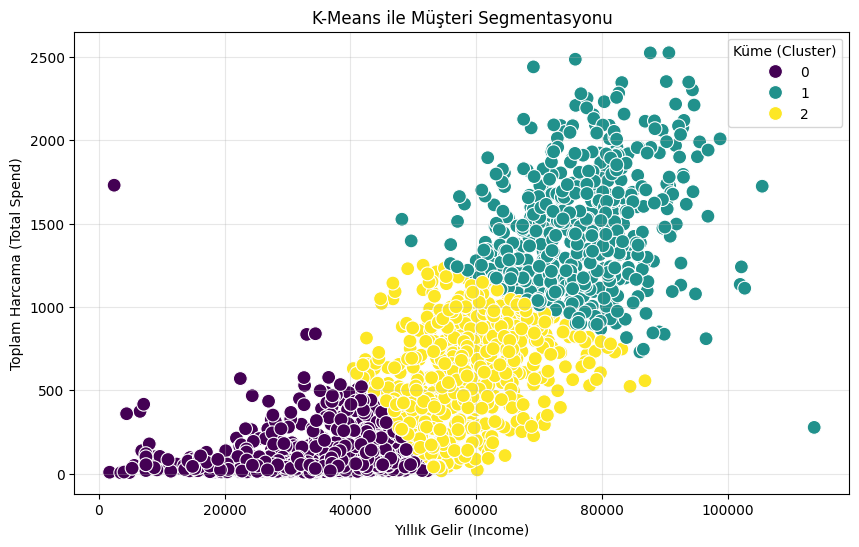

In [32]:
#1. K-Means modelini K=3 olacak şekilde kuruyoruz
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Modeli eğitiyor ve müşterilerin hangi kümeye (0, 1 veya 2) ait olduğunu buluyoruz
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Sonuçları Görselleştirme
plt.figure(figsize=(10, 6))

# seaborn ile scatter plot (dağılım grafiği) çizdiriyoruz
sns.scatterplot(x='Income', y='Total_Spend', hue='Cluster', data=df, palette='viridis', s=100)

plt.title('K-Means ile Müşteri Segmentasyonu')
plt.xlabel('Yıllık Gelir (Income)')
plt.ylabel('Toplam Harcama (Total Spend)')
plt.legend(title='Küme (Cluster)')
plt.grid(True, alpha=0.3)
plt.show()